# UAE Healthcare Dataset - EDA

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. LOAD THE DATA

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df = df.drop_duplicates().reset_index(drop=True)

for col in ["Diagnosis_Date", "Treatment_Start_Date", "Death_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["BMI"] = df["Weight"] / (df["Height"] / 100) ** 2

print(f"Dataset loaded: {len(df):,} patients, {df.shape[1]} columns")
print(f"\nOutcome distribution:\n{df['Outcome'].value_counts()}")

Saving _cancer_dataset_uae.csv to _cancer_dataset_uae (2).csv
Dataset loaded: 10,000 patients, 21 columns

Outcome distribution:
Outcome
Recovered          4931
Under Treatment    4077
Deceased            992
Name: count, dtype: int64


In [3]:
# 2. INSPECT THE DATA

print("\nFirst 5 rows:")
print(df.head())

print(f"\nShape (rows, columns): {df.shape}")

print("\nColumn info:")
df.info()


First 5 rows:
  Patient_ID  Age  Gender Nationality        Emirate Diagnosis_Date  \
0  PAT000001   69  Female     Emirati  Umm Al Quwain     2020-11-30   
1  PAT000002   32    Male     Emirati  Umm Al Quwain     2015-10-10   
2  PAT000003   89    Male     Emirati      Abu Dhabi     2018-02-13   
3  PAT000004   78  Female     Emirati      Abu Dhabi     2022-02-04   
4  PAT000005   38  Female     Emirati       Fujairah     2019-12-03   

  Cancer_Type Cancer_Stage Treatment_Type Treatment_Start_Date  ...  \
0       Liver           II      Radiation           2020-12-04  ...   
1    Leukemia          III        Surgery           2015-11-05  ...   
2       Liver          III      Radiation           2018-08-03  ...   
3        Lung          III      Radiation           2022-03-13  ...   
4  Pancreatic           II   Chemotherapy           2020-02-29  ...   

  Primary_Physician          Outcome Death_Date Cause_of_Death Smoking_Status  \
0          Dr. VO41        Recovered        NaT   

In [4]:
# 3. CHECK FOR MISSING VALUES

print("\nMissing values per column:")
print(df.isna().sum())

print("\nRows where Cause_of_Death is missing (patient is still alive):")
print(df[df["Cause_of_Death"].isna()][["Outcome", "Death_Date", "Cause_of_Death"]].head())


Missing values per column:
Patient_ID                 0
Age                        0
Gender                     0
Nationality                0
Emirate                    0
Diagnosis_Date             0
Cancer_Type                0
Cancer_Stage               0
Treatment_Type             0
Treatment_Start_Date       0
Hospital                   0
Primary_Physician          0
Outcome                    0
Death_Date              9008
Cause_of_Death          9008
Smoking_Status             0
Comorbidities           4047
Ethnicity                  0
Weight                     0
Height                     0
BMI                        0
dtype: int64

Rows where Cause_of_Death is missing (patient is still alive):
           Outcome Death_Date Cause_of_Death
0        Recovered        NaT            NaN
1        Recovered        NaT            NaN
2  Under Treatment        NaT            NaN
3        Recovered        NaT            NaN
4        Recovered        NaT            NaN


In [5]:
# 4. CHECK FOR DUPLICATES

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [6]:
# 5. FEATURE ENGINEERING — AGE CATEGORIES

print(f"\nNumber of unique ages: {df['Age'].nunique()}")
print(f"Unique ages: {sorted(df['Age'].unique())}")

print("\nAge summary statistics:")
print(df["Age"].describe())

minimum     = df["Age"].min()          # youngest patient (18)
q25         = df["Age"].quantile(0.25) # 25th percentile (36)
median      = df["Age"].median()       # 50th percentile (53)
q75         = df["Age"].quantile(0.75) # 75th percentile (72)
maximum     = df["Age"].max()          # oldest patient (89)

bins   = [minimum - 1, q25, median, q75, maximum]
labels = ["young_adult", "middle_age", "older_adult", "elderly"]

df["Age_cat"] = pd.cut(df["Age"], bins=bins, labels=labels)

print("\nAge vs Age category (sample):")
print(df[["Age", "Age_cat"]].head(10))
print("\nPatients per age category:")
print(df["Age_cat"].value_counts())


Number of unique ages: 72
Unique ages: [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int6

In [7]:
# 6. CHECK FOR INCONSISTENT VALUES

print("\nUnique values per column (scan for inconsistencies):")
for col in df.columns:
    if col in ["Patient_ID", "Primary_Physician",
               "Diagnosis_Date", "Treatment_Start_Date", "Death_Date"]:
        print(f"\n{col}: ({df[col].nunique()} unique values — too many to list)")
        continue
    print(f"\n{col}: {df[col].unique()}")


Unique values per column (scan for inconsistencies):

Patient_ID: (10000 unique values — too many to list)

Age: [69 32 89 78 38 41 20 39 70 19 47 55 81 77 50 75 66 76 59 79 64 68 72 24
 56 35 21 31 26 88 61 25 52 53 67 23 71 80 51 65 57 43 58 46 62 82 18 28
 22 45 29 40 54 44 60 30 49 83 74 87 73 36 85 34 86 33 37 84 48 42 63 27]

Gender: ['Female' 'Male' 'Other']

Nationality: ['Emirati' 'Expatriate']

Emirate: ['Umm Al Quwain' 'Abu Dhabi' 'Fujairah' 'Ras Al Khaimah' 'Sharjah' 'Dubai'
 'Ajman']

Diagnosis_Date: (3151 unique values — too many to list)

Cancer_Type: ['Liver' 'Leukemia' 'Lung' 'Pancreatic' 'Breast' 'Ovarian' 'Prostate'
 'Colorectal']

Cancer_Stage: ['II' 'III' 'I' 'IV']

Treatment_Type: ['Radiation' 'Surgery' 'Chemotherapy' 'Immunotherapy']

Treatment_Start_Date: (3250 unique values — too many to list)

Hospital: ['Sheikh Khalifa Hospital' 'Dubai Hospital' 'Zayed Military Hospital'
 'Cleveland Clinic Abu Dhabi']

Primary_Physician: (8614 unique values — too many to lis

In [8]:
# 7. STATISTICAL SUMMARY

print("\nNumeric column summary:")
print(df[["Age", "Weight", "Height", "BMI"]].describe())

print("\nCategorical column summary:")
print(df.select_dtypes(include="object").describe())


Numeric column summary:
                Age        Weight        Height           BMI
count  10000.000000  10000.000000  10000.000000  10000.000000
mean      53.539700     69.550000    169.347500     24.503744
std       20.757324     14.933339     10.070118      6.038208
min       18.000000     18.000000    131.000000      5.673505
25%       36.000000     60.000000    163.000000     20.305175
50%       53.000000     70.000000    169.000000     24.128792
75%       72.000000     80.000000    176.000000     28.384802
max       89.000000    122.000000    208.000000     53.374656

Categorical column summary:
       Patient_ID  Gender Nationality Emirate Cancer_Type Cancer_Stage  \
count       10000   10000       10000   10000       10000        10000   
unique      10000       3           2       7           8            4   
top     PAT009984  Female     Emirati   Ajman    Leukemia          III   
freq            1    4985        5920    1497        1314         3041   

       Treatment_

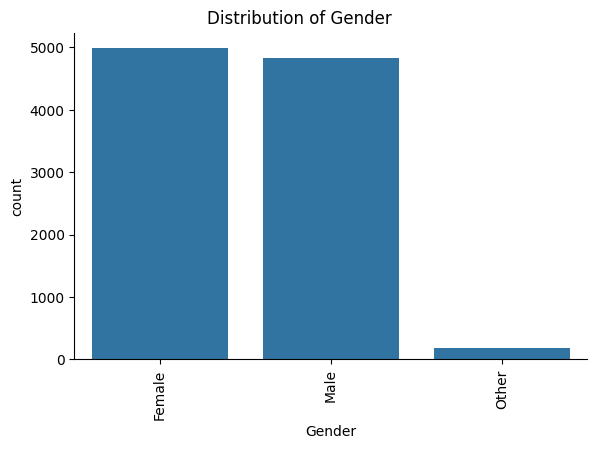

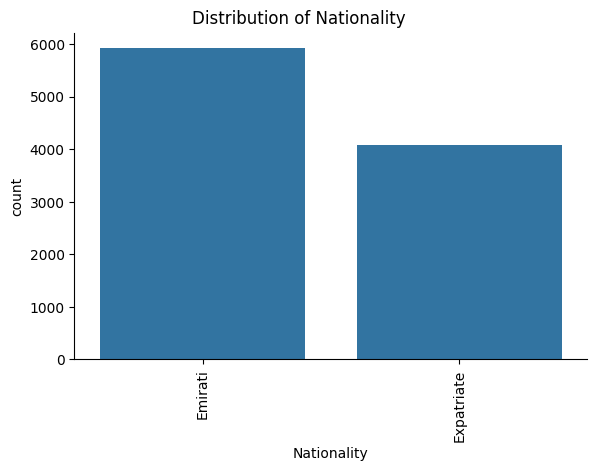

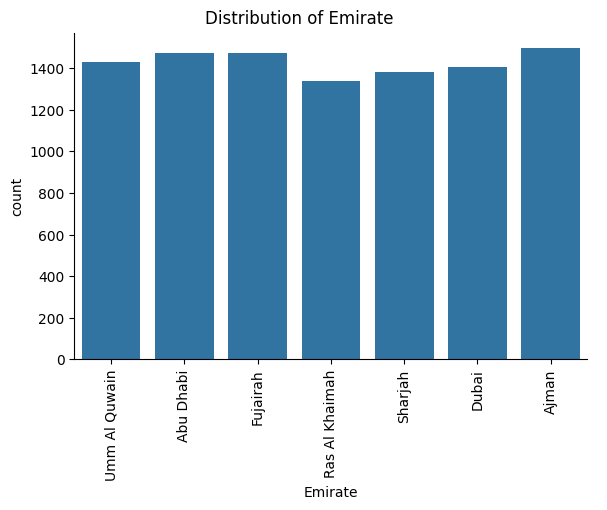

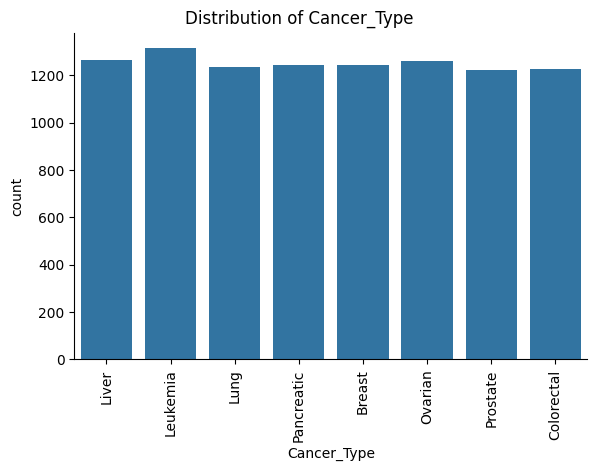

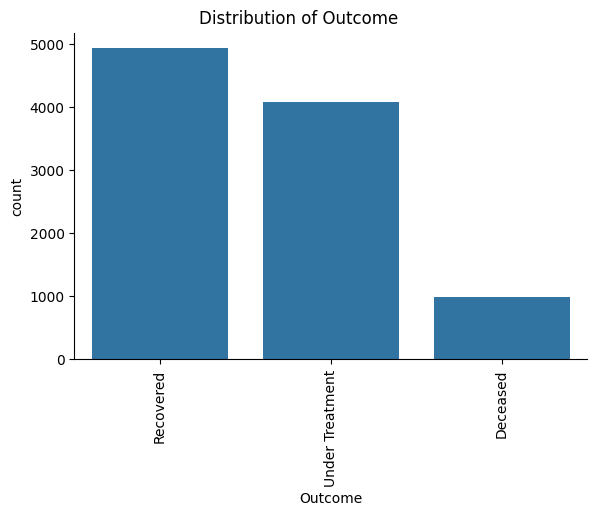

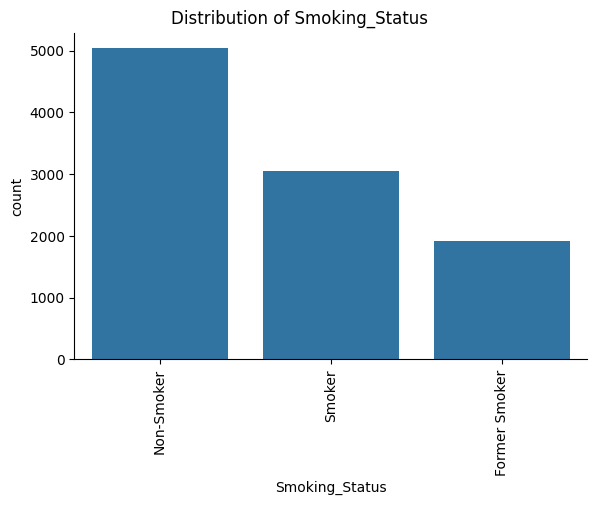

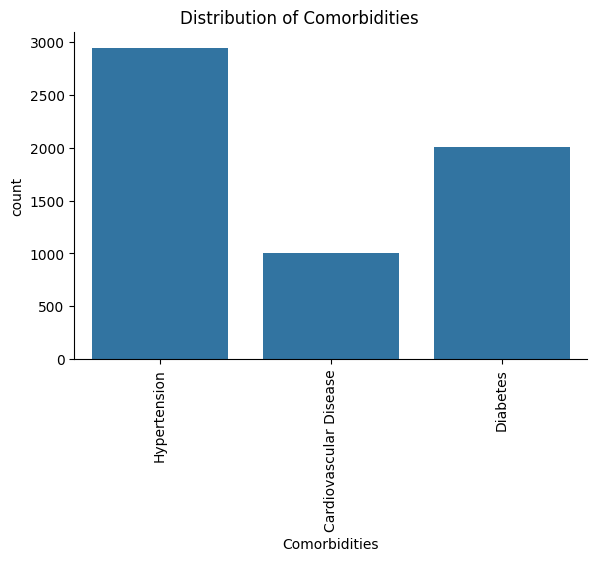

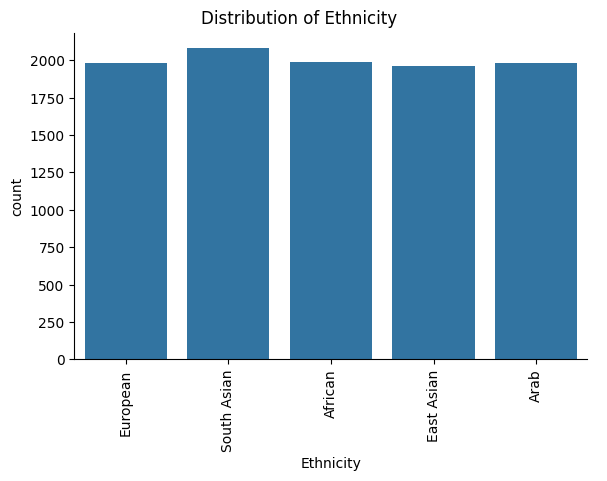

In [9]:
# 8. VISUALIZATION — CATEGORICAL COLUMNS

categorical_cols = ["Gender", "Nationality", "Emirate", "Cancer_Type",
                    "Outcome", "Smoking_Status", "Comorbidities", "Ethnicity"]

def plot_categorical_distributions(columns):
    """Draw a count plot for each categorical column."""
    for col in columns:
        g = sns.catplot(x=col, data=df, kind="count", height=4, aspect=1.5)
        g.set_xticklabels(rotation=90)
        g.fig.suptitle(f"Distribution of {col}", y=1.02)
        plt.show()

plot_categorical_distributions(categorical_cols)

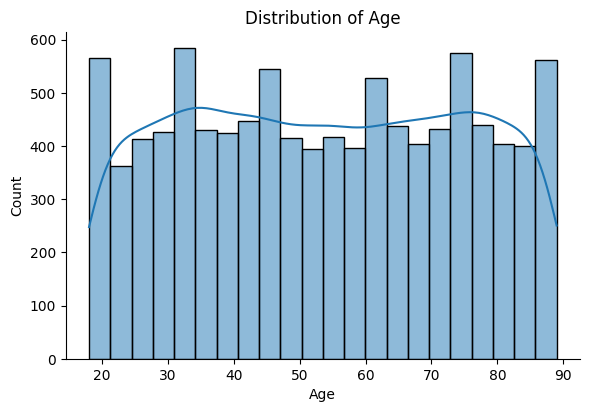

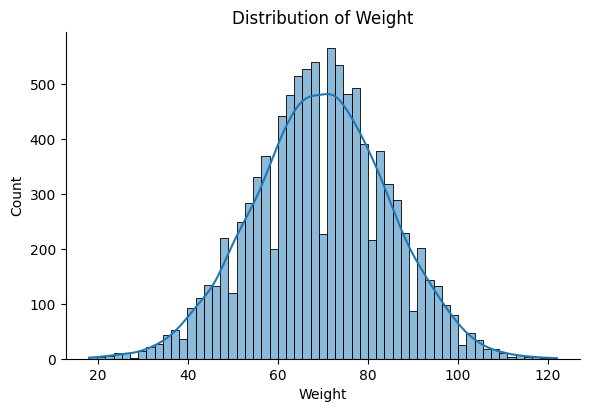

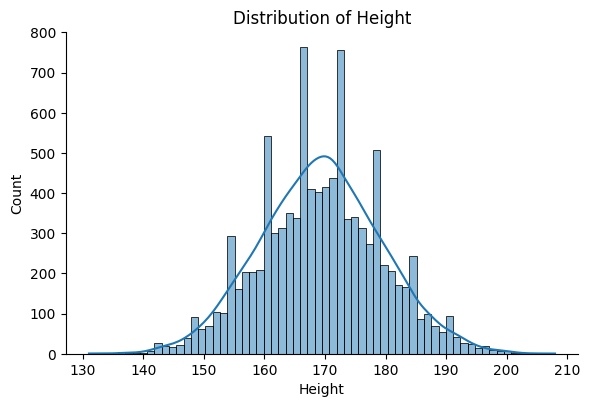

In [10]:
# 9. VISUALIZATION — NUMERIC COLUMNS

numeric_cols = ["Age", "Weight", "Height"]

def plot_numeric_distributions(columns):
    """Draw a distribution plot for each numeric column."""
    for col in columns:
        sns.displot(df[col], height=4, aspect=1.5, kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

plot_numeric_distributions(numeric_cols)